In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [8]:
import os

# Check current directory
print(f"Current directory: {os.getcwd()}")

# List contents of current directory
print(f"\n📁 Contents of /content:")
for item in os.listdir('/content'):
    print(f"  - {item}")

# Check if dataset folder exists
if os.path.exists('/content/dataset'):
    print(f"\n📁 Contents of /content/dataset:")
    for item in os.listdir('/content/dataset'):
        full_path = os.path.join('/content/dataset', item)
        size = os.path.getsize(full_path) if os.path.isfile(full_path) else 'folder'
        print(f"  - {item} ({size} bytes)" if size != 'folder' else f"  - {item}/ (folder)")
else:
    print("\n❌ /content/dataset folder does not exist")

# Check specific files
train_path = '/content/dataset/KDDTrain+.txt'
test_path = '/content/dataset/KDDTest+.txt'

print(f"\n🔍 File checks:")
print(f"  Train file exists: {os.path.exists(train_path)}")
print(f"  Test file exists: {os.path.exists(test_path)}")

if os.path.exists(train_path):
    print(f"  Train file size: {os.path.getsize(train_path):,} bytes")
if os.path.exists(test_path):
    print(f"  Test file size: {os.path.getsize(test_path):,} bytes")

Current directory: /content

📁 Contents of /content:
  - .config
  - .ipynb_checkpoints
  - dataset

📁 Contents of /content/dataset:
  - KDDTest+.txt (3441513 bytes)
  - california_housing_train.csv (1706430 bytes)
  - KDDTrain+.txt (19109424 bytes)
  - README.md (962 bytes)
  - anscombe.json (1697 bytes)
  - mnist_train_small.csv (36523880 bytes)
  - mnist_test.csv (18289443 bytes)
  - california_housing_test.csv (301141 bytes)

🔍 File checks:
  Train file exists: True
  Test file exists: True
  Train file size: 19,109,424 bytes
  Test file size: 3,441,513 bytes


In [9]:
import pandas as pd

column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

# Direct load
train_data = pd.read_csv('/content/dataset/KDDTrain+.txt', names=column_names, header=None)
test_data = pd.read_csv('/content/dataset/KDDTest+.txt', names=column_names, header=None)

print(f"✅ Training Data Shape: {train_data.shape}")
print(f"✅ Test Data Shape: {test_data.shape}")
print(f"\n🎉 Data loaded successfully!")

✅ Training Data Shape: (125973, 43)
✅ Test Data Shape: (22544, 43)

🎉 Data loaded successfully!


In [10]:
# Display first few rows
print("\n📋 First 5 rows of Training Data:")
train_data.head()


📋 First 5 rows of Training Data:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [11]:
# Dataset information
print("\n📊 Dataset Info:")
train_data.info()


📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-n

In [12]:
# Statistical summary
print("\n📈 Statistical Summary (Numerical Features):")
train_data.describe()


📈 Statistical Summary (Numerical Features):


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [13]:
# Check for missing values
print("\n🔍 Missing Values:")
missing = train_data.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    print(missing[missing > 0])


🔍 Missing Values:
✅ No missing values found!


In [14]:
# Identify textual (categorical) columns
textual_features = ['protocol_type', 'service', 'flag', 'label']

print("\n📝 Textual Features Overview:\n")
for feature in textual_features:
    unique_count = train_data[feature].nunique()
    print(f"{feature:20s} - {unique_count:3d} unique values")



📝 Textual Features Overview:

protocol_type        -   3 unique values
service              -  70 unique values
flag                 -  11 unique values
label                -  23 unique values



🌐 Protocol Type Distribution:
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64


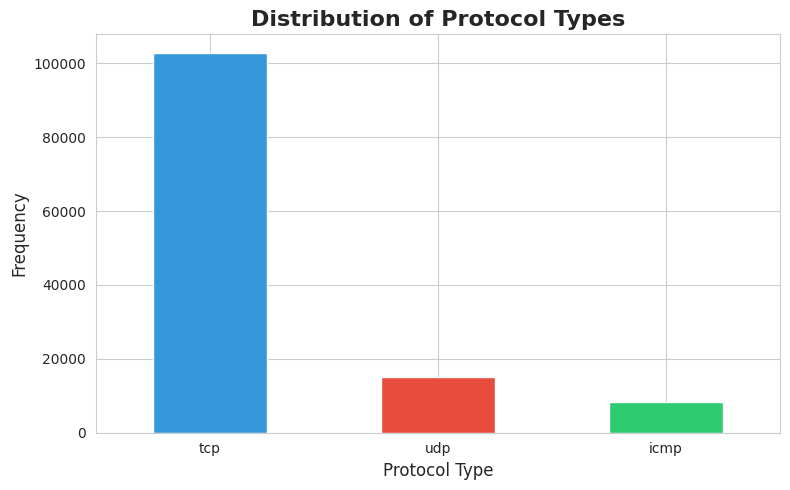

In [15]:
# Protocol Type Distribution
print("\n🌐 Protocol Type Distribution:")
print(train_data['protocol_type'].value_counts())

# Visualization
plt.figure(figsize=(8, 5))
train_data['protocol_type'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Distribution of Protocol Types', fontsize=16, fontweight='bold')
plt.xlabel('Protocol Type', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


🔧 Top 15 Services:
service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
ftp          1754
auth          955
Z39_50        862
uucp          780
courier       734
Name: count, dtype: int64


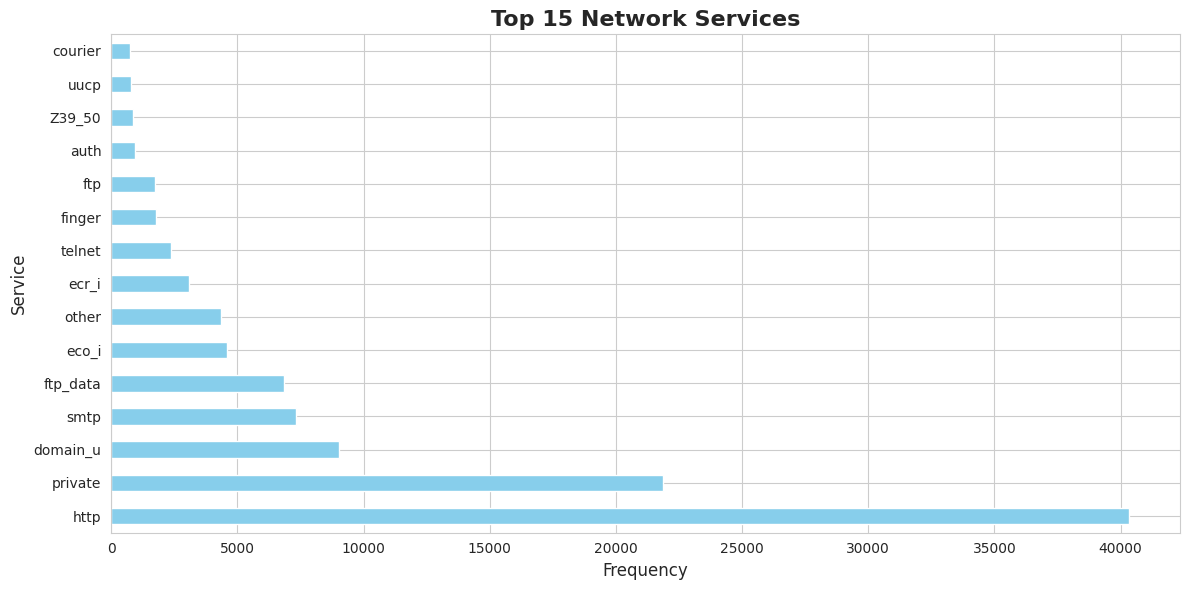

In [16]:
# Service Distribution (Top 15)
print("\n🔧 Top 15 Services:")
print(train_data['service'].value_counts().head(15))

# Visualization
plt.figure(figsize=(12, 6))
train_data['service'].value_counts().head(15).plot(kind='barh', color='skyblue')
plt.title('Top 15 Network Services', fontsize=16, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Service', fontsize=12)
plt.tight_layout()
plt.show()


🚩 Connection Flag Distribution:
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64


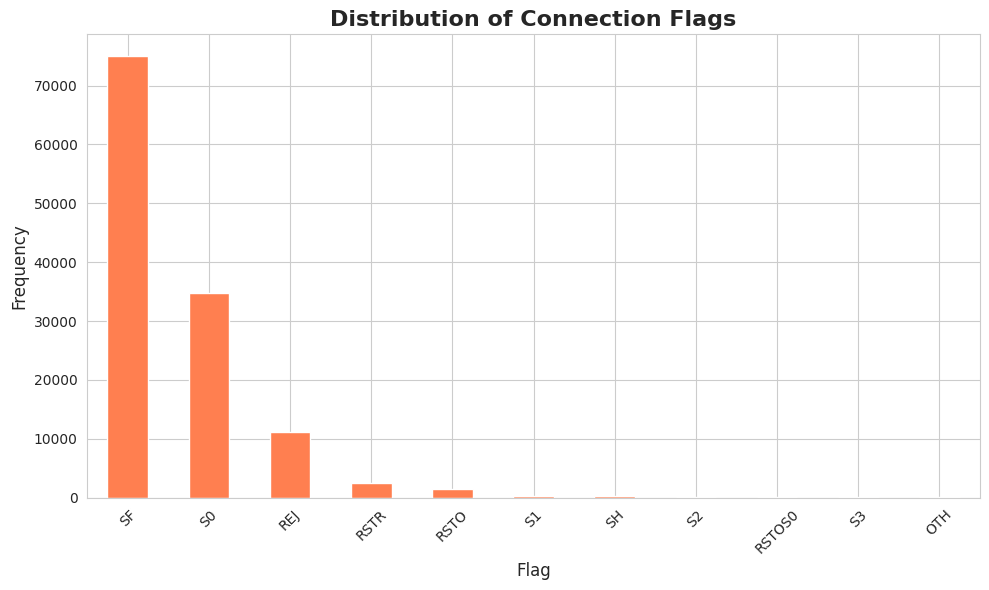

In [17]:
# Flag Distribution
print("\n🚩 Connection Flag Distribution:")
print(train_data['flag'].value_counts())

# Visualization
plt.figure(figsize=(10, 6))
train_data['flag'].value_counts().plot(kind='bar', color='coral')
plt.title('Distribution of Connection Flags', fontsize=16, fontweight='bold')
plt.xlabel('Flag', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


⚠️ Attack Type Distribution:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


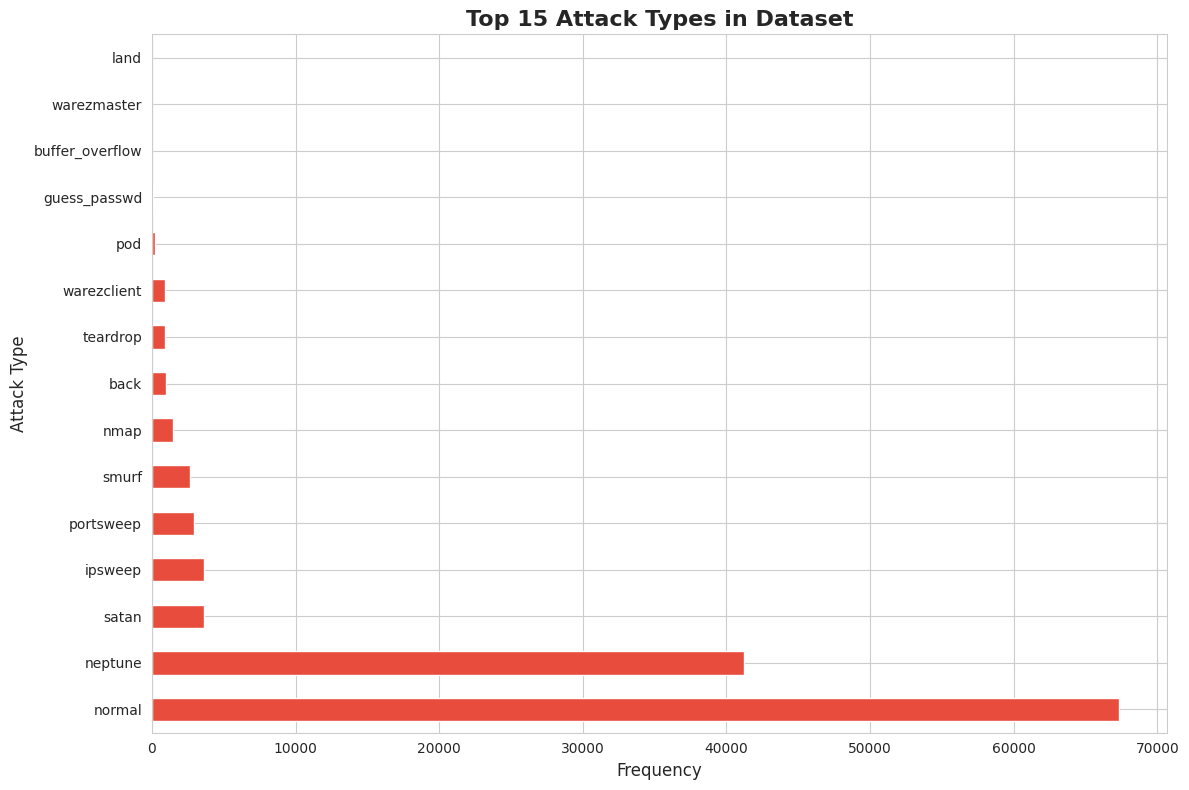

In [18]:
# Attack Type Distribution
print("\n⚠️ Attack Type Distribution:")
print(train_data['label'].value_counts())

# Visualization
plt.figure(figsize=(12, 8))
train_data['label'].value_counts().head(15).plot(kind='barh', color='#e74c3c')
plt.title('Top 15 Attack Types in Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Attack Type', fontsize=12)
plt.tight_layout()
plt.show()


📊 Normal vs Attack Distribution:
is_attack
0    67343
1    58630
Name: count, dtype: int64


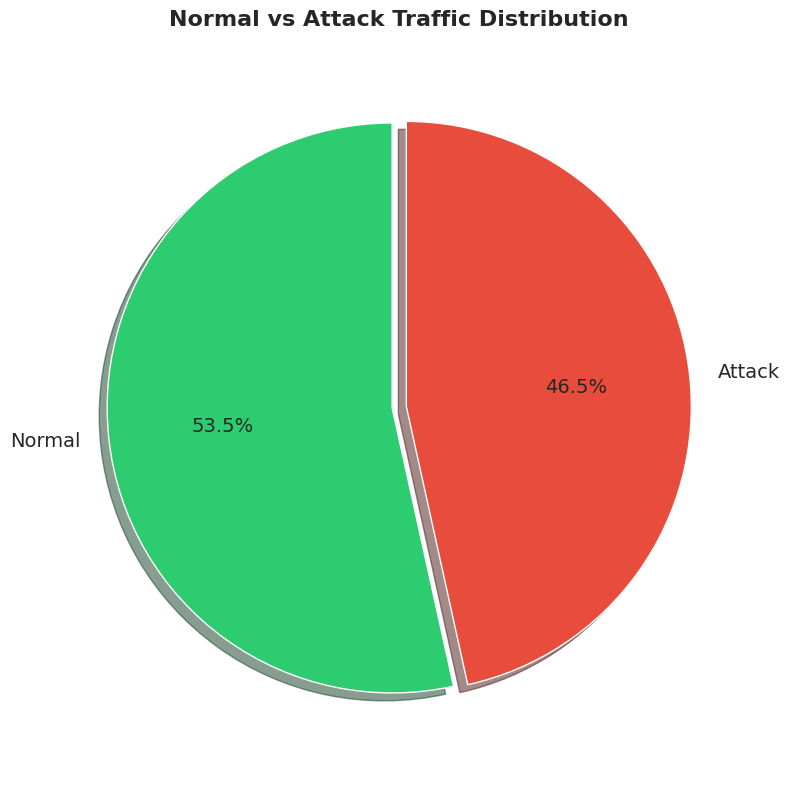

In [19]:
# Binary Classification: Normal vs Attack
train_data['is_attack'] = train_data['label'].apply(lambda x: 0 if x == 'normal' else 1)

print("\n📊 Normal vs Attack Distribution:")
print(train_data['is_attack'].value_counts())

# Pie chart
plt.figure(figsize=(8, 8))
labels = ['Normal', 'Attack']
sizes = train_data['is_attack'].value_counts()
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0)

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 14})
plt.title('Normal vs Attack Traffic Distribution', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [20]:
# Word frequency-like analysis for textual features
def analyze_text_frequency(column_name):
    """
    Analyze frequency of values in textual columns
    Similar to word frequency in text analysis
    """
    freq = train_data[column_name].value_counts()
    print(f"\n{'='*60}")
    print(f"📊 {column_name.upper()} Frequency Analysis")
    print(f"{'='*60}")
    print(f"Total Unique Values: {len(freq)}")
    print(f"Most Common: {freq.index[0]} ({freq.values[0]:,} occurrences)")
    print(f"Least Common: {freq.index[-1]} ({freq.values[-1]:,} occurrences)")
    print(f"\nTop 10:")
    print(freq.head(10))

# Analyze all textual features
for feature in ['protocol_type', 'service', 'flag']:
    analyze_text_frequency(feature)


📊 PROTOCOL_TYPE Frequency Analysis
Total Unique Values: 3
Most Common: tcp (102,689 occurrences)
Least Common: icmp (8,291 occurrences)

Top 10:
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

📊 SERVICE Frequency Analysis
Total Unique Values: 70
Most Common: http (40,338 occurrences)
Least Common: http_2784 (1 occurrences)

Top 10:
service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
Name: count, dtype: int64

📊 FLAG Frequency Analysis
Total Unique Values: 11
Most Common: SF (74,945 occurrences)
Least Common: OTH (46 occurrences)

Top 10:
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
Name: count, dtype: int64


In [21]:
# Display sample normal connections
print("\n✅ Sample NORMAL Connections:")
normal_samples = train_data[train_data['label'] == 'normal'][['protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'label']].head(5)
print(normal_samples)


✅ Sample NORMAL Connections:
   protocol_type   service flag  src_bytes  dst_bytes   label
0            tcp  ftp_data   SF        491          0  normal
1            udp     other   SF        146          0  normal
3            tcp      http   SF        232       8153  normal
4            tcp      http   SF        199        420  normal
12           tcp      http   SF        287       2251  normal


In [22]:
# Display sample attack connections
print("\n⚠️ Sample ATTACK Connections:")
attack_samples = train_data[train_data['label'] != 'normal'][['protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'label']].head(10)
print(attack_samples)


⚠️ Sample ATTACK Connections:
   protocol_type     service flag  src_bytes  dst_bytes        label
2            tcp     private   S0          0          0      neptune
5            tcp     private  REJ          0          0      neptune
6            tcp     private   S0          0          0      neptune
7            tcp     private   S0          0          0      neptune
8            tcp  remote_job   S0          0          0      neptune
9            tcp     private   S0          0          0      neptune
10           tcp     private  REJ          0          0      neptune
11           tcp     private   S0          0          0      neptune
13           tcp    ftp_data   SF        334          0  warezclient
14           tcp        name   S0          0          0      neptune


In [23]:
# Analyze 'length' of textual features (character count)
print("\n📏 Textual Feature Length Statistics:\n")

for feature in ['protocol_type', 'service', 'flag', 'label']:
    train_data[f'{feature}_length'] = train_data[feature].astype(str).apply(len)
    print(f"{feature}:")
    print(f"  Min Length: {train_data[f'{feature}_length'].min()}")
    print(f"  Max Length: {train_data[f'{feature}_length'].max()}")
    print(f"  Avg Length: {train_data[f'{feature}_length'].mean():.2f}")
    print()


📏 Textual Feature Length Statistics:

protocol_type:
  Min Length: 3
  Max Length: 4
  Avg Length: 3.07

service:
  Min Length: 3
  Max Length: 11
  Avg Length: 5.47

flag:
  Min Length: 2
  Max Length: 6
  Avg Length: 2.16

label:
  Min Length: 3
  Max Length: 15
  Avg Length: 6.39



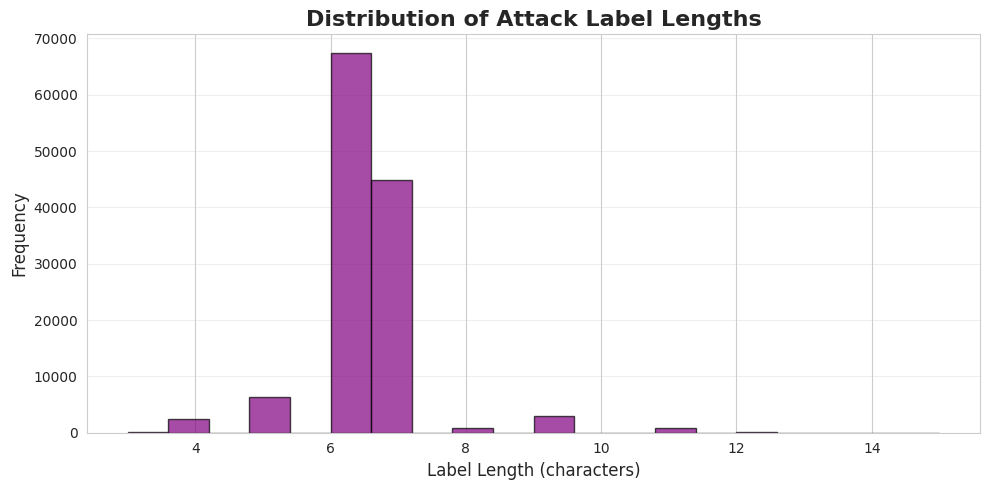

In [24]:
# Visualize label length distribution
plt.figure(figsize=(10, 5))
plt.hist(train_data['label_length'], bins=20, color='purple', alpha=0.7, edgecolor='black')
plt.title('Distribution of Attack Label Lengths', fontsize=16, fontweight='bold')
plt.xlabel('Label Length (characters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# Categorize attacks into main types
dos_attacks = ['neptune', 'smurf', 'pod', 'teardrop', 'land', 'back', 'apache2', 'udpstorm', 'processtable', 'mailbomb']
probe_attacks = ['satan', 'ipsweep', 'nmap', 'portsweep', 'mscan', 'saint']
r2l_attacks = ['guess_passwd', 'ftp_write', 'imap', 'phf', 'multihop', 'warezmaster', 'warezclient', 'spy', 'xlock', 'xsnoop', 'snmpguess', 'snmpgetattack', 'httptunnel', 'sendmail', 'named']
u2r_attacks = ['buffer_overflow', 'loadmodule', 'rootkit', 'perl', 'sqlattack', 'xterm', 'ps']

def categorize_attack(label):
    if label == 'normal':
        return 'Normal'
    elif label in dos_attacks:
        return 'DoS'
    elif label in probe_attacks:
        return 'Probe'
    elif label in r2l_attacks:
        return 'R2L'
    elif label in u2r_attacks:
        return 'U2R'
    else:
        return 'Other'

train_data['attack_category'] = train_data['label'].apply(categorize_attack)

print("\n🎯 Attack Categories Distribution:")
print(train_data['attack_category'].value_counts())


🎯 Attack Categories Distribution:
attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


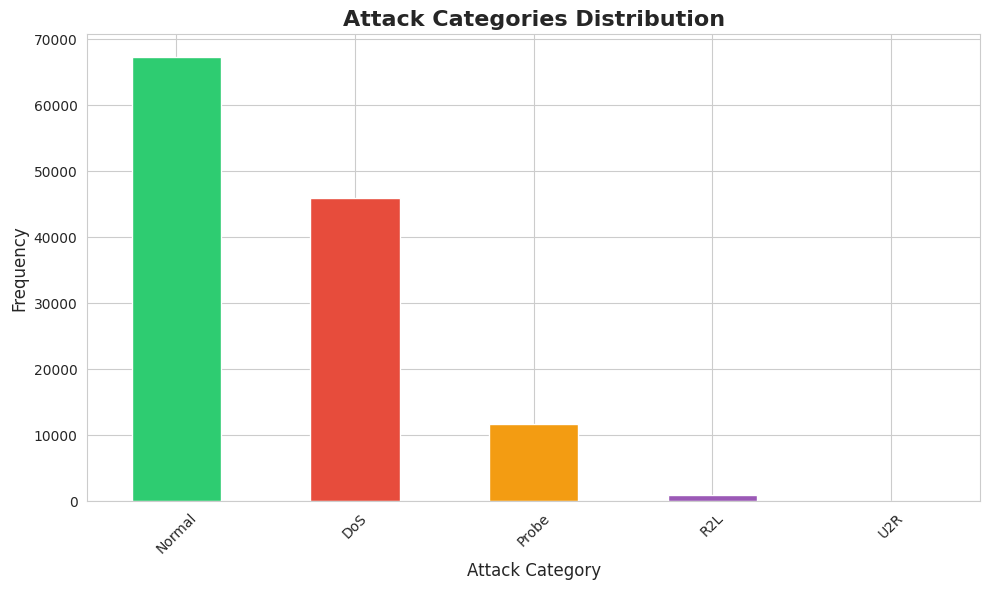

In [26]:
# Visualize attack categories
plt.figure(figsize=(10, 6))
category_counts = train_data['attack_category'].value_counts()
colors_map = {'Normal': '#2ecc71', 'DoS': '#e74c3c', 'Probe': '#f39c12', 'R2L': '#9b59b6', 'U2R': '#3498db', 'Other': '#95a5a6'}
colors = [colors_map.get(x, '#95a5a6') for x in category_counts.index]

category_counts.plot(kind='bar', color=colors)
plt.title('Attack Categories Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Attack Category', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
print("\n" + "="*70)
print("📋 MODULE 1: EXPLORATION & ANALYSIS - SUMMARY REPORT")
print("="*70)

print("\n1️⃣ DATASET INFORMATION:")
print(f"   📦 Dataset Name: NSL-KDD Network Intrusion Detection")
print(f"   🔗 Source: Kaggle (https://www.kaggle.com/datasets/hassan06/nslkdd)")
print(f"   📊 Data Type: Network Traffic (Textual + Numerical)")
print(f"   🎯 Problem Domain: Cybersecurity - Network Anomaly Detection")

print("\n2️⃣ DATASET SIZE:")
print(f"   📈 Training Samples: {train_data.shape[0]:,}")
print(f"   🧪 Test Samples: {test_data.shape[0]:,}")
print(f"   📊 Total Features: {train_data.shape[1]}")
print(f"   📝 Textual Features: {len(textual_features)}")
print(f"   🔢 Numerical Features: {train_data.shape[1] - len(textual_features)}")

print("\n3️⃣ KEY TEXTUAL FEATURES:")
print(f"   🌐 Protocol Types: {train_data['protocol_type'].nunique()} types (tcp, udp, icmp)")
print(f"   🔧 Network Services: {train_data['service'].nunique()} services (http, ftp, smtp, etc.)")
print(f"   🚩 Connection Flags: {train_data['flag'].nunique()} flags (SF, S0, REJ, etc.)")
print(f"   ⚠️ Attack Labels: {train_data['label'].nunique()} unique attack types")

print("\n4️⃣ ATTACK DISTRIBUTION:")
normal_count = (train_data['label'] == 'normal').sum()
attack_count = (train_data['label'] != 'normal').sum()
print(f"   ✅ Normal Traffic: {normal_count:,} ({normal_count/len(train_data)*100:.1f}%)")
print(f"   ⚠️ Attack Traffic: {attack_count:,} ({attack_count/len(train_data)*100:.1f}%)")

print("\n5️⃣ ATTACK CATEGORIES:")
for category, count in train_data['attack_category'].value_counts().items():
    print(f"   • {category}: {count:,} ({count/len(train_data)*100:.1f}%)")

print("\n6️⃣ DATA QUALITY:")
print(f"   ✅ Missing Values: {train_data.isnull().sum().sum()} (0%)")
print(f"   ✅ Duplicate Rows: {train_data.duplicated().sum()}")

print("\n" + "="*70)
print("✅ MODULE 1 COMPLETED SUCCESSFULLY!")
print("="*70)


📋 MODULE 1: EXPLORATION & ANALYSIS - SUMMARY REPORT

1️⃣ DATASET INFORMATION:
   📦 Dataset Name: NSL-KDD Network Intrusion Detection
   🔗 Source: Kaggle (https://www.kaggle.com/datasets/hassan06/nslkdd)
   📊 Data Type: Network Traffic (Textual + Numerical)
   🎯 Problem Domain: Cybersecurity - Network Anomaly Detection

2️⃣ DATASET SIZE:
   📈 Training Samples: 125,973
   🧪 Test Samples: 22,544
   📊 Total Features: 49
   📝 Textual Features: 4
   🔢 Numerical Features: 45

3️⃣ KEY TEXTUAL FEATURES:
   🌐 Protocol Types: 3 types (tcp, udp, icmp)
   🔧 Network Services: 70 services (http, ftp, smtp, etc.)
   🚩 Connection Flags: 11 flags (SF, S0, REJ, etc.)
   ⚠️ Attack Labels: 23 unique attack types

4️⃣ ATTACK DISTRIBUTION:
   ✅ Normal Traffic: 67,343 (53.5%)
   ⚠️ Attack Traffic: 58,630 (46.5%)

5️⃣ ATTACK CATEGORIES:
   • Normal: 67,343 (53.5%)
   • DoS: 45,927 (36.5%)
   • Probe: 11,656 (9.3%)
   • R2L: 995 (0.8%)
   • U2R: 52 (0.0%)

6️⃣ DATA QUALITY:
   ✅ Missing Values: 0 (0%)
   ✅ Dup

In [28]:
# Save with attack categories for Module 2
train_save_path = os.path.join(current_dir, 'dataset', 'train_with_categories.csv')
test_save_path = os.path.join(current_dir, 'dataset', 'test_with_categories.csv')

train_data.to_csv(train_save_path, index=False)
test_data_categorized = test_data.copy()
test_data_categorized['is_attack'] = test_data_categorized['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_data_categorized['attack_category'] = test_data_categorized['label'].apply(categorize_attack)
test_data_categorized.to_csv(test_save_path, index=False)

print("\n💾 Processed data saved successfully!")
print(f"   ✅ {train_save_path}")
print(f"   ✅ {test_save_path}")
print("\n🚀 Ready for Module 2: Preprocessing!")


💾 Processed data saved successfully!
   ✅ /content/dataset/train_with_categories.csv
   ✅ /content/dataset/test_with_categories.csv

🚀 Ready for Module 2: Preprocessing!
